## Satellite Simulation Notebook
- Author Brandon Engelbrecht

In [1]:
%load_ext autoreload
%autoreload 2

%reload_ext autoreload

In [24]:
from satellite_RFI.src.satellite_sims import satellite_sim as ss
import time
import pickle
import astropy.units as u
from datetime import datetime


import scipy as sp
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt

In [3]:
katdal_info = pickle.load(open('../../Outputs/1551055211_level6_mask/1551055211_katdal_info.p', 'rb'))
info = [katdal_info[i] for i in katdal_info.keys()]

obs_time_input='2019 2 25 0 40 11'
tle_location='TLE/2019_02_21_tle/'

nd_s0=info[0]
nd_s0_coords=info[2]
frequency=info[1]
fs=1000
fe=1500

data_save='../../Outputs/'

 


In [4]:
"""
Establishing the file name
"""
obs_time_in=[int(x) for x in obs_time_input.split()]
obs_time = datetime(obs_time_in[0], obs_time_in[1], obs_time_in[2], obs_time_in[3], obs_time_in[4], obs_time_in[5])
fname = str(int((obs_time - datetime(1970, 1, 1)).total_seconds()))
print "File name to be used is: ", fname

File name to be used is:  1551055211


In [5]:

data_mkat = '../../Outputs/'+str(fname)+'_level6_mask/'



s_time = time.time()
emss_b = ss(file_name=fname, sats_only=None, data_loc=data_mkat,sat_loc='../../Outputs/',
            survey_info=[nd_s0, nd_s0_coords, frequency], plots_loc='../../../Plots/',
            sat_catalogue_name='table3B_satellite_v3.csv', sat_catalogue_loc='Satellite_Catalogue/', 
            sat_beam='emss_beam', frequency_range=[fs,fe])
print time.time() - s_time

print 'Done \n'



8.65711808205
Done 



In [6]:
#             file_bias_choice=[0.5, 0.7, 0.3, 0],
#             file_bias_choice=[0.1, 0.4, 0.22, 0.5, 0.55, 0.25, 0],  # 2000-2100sec 

In [84]:
s_time = time.time()
emss_b.excecute(obs_time_start=2000, obs_time_end=2100, obs_frequency_start=1200, obs_frequency_end=1300, 
            file_bias_choice=[0.3, 0.6, 0.6, 0.5, 0.4, 0.3, 0],  # 2000-2100sec                
            add_sub=[1, 1], band_lvl=[25, 1])
print time.time() - s_time



Time between: 2002.235434293747 and 2102.193146467209 in seconds

Frequency between: 1200.0 and 1300.3 in MHz

Bias choice is follows:gps-ops, glo-ops, galileo, beidou, irnss, sbas, noise
2.3095510006


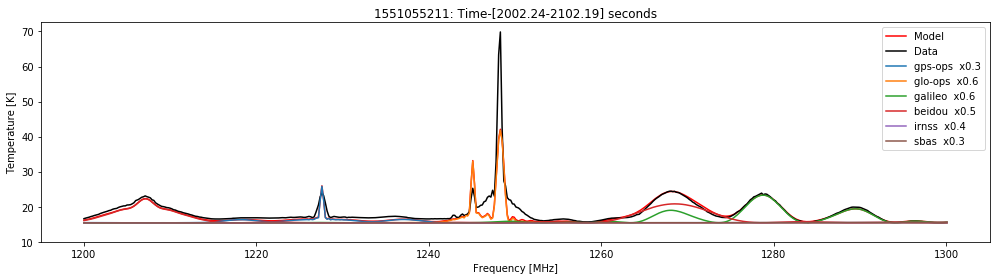

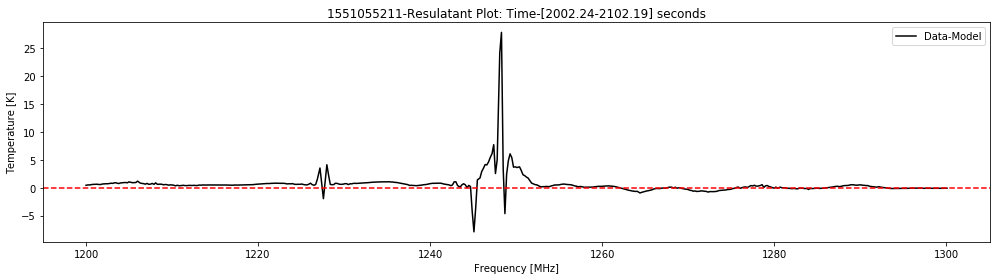

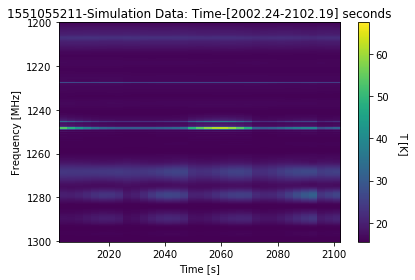

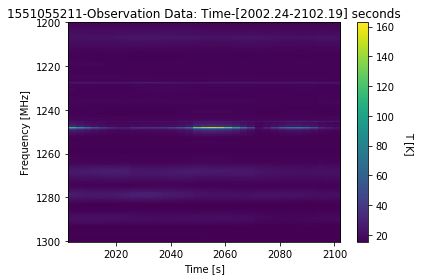

In [85]:
emss_b.plotting(individual=1, logger=1, axis_limit=[None, None, 10, None], tod_limit=None, save_file=None, file_type='png')


In [22]:
emss_b.simulation_TOD_slice.shape - emss_b.simulation_slice

masked_array(data=[0.0, 0.0, 0.0, ..., 0.0, 0.0, 0.0],
             mask=[False, False, False, ..., False, False, False],
       fill_value=1e+20)

### setting up chi_square

In [86]:
simulation = emss_b.simulation_slice
observation = emss_b._average_over_frequency_(emss_b.calibration_data_slice)

print simulation.shape
print observation.shape

(480,)
(480,)


In [55]:
error = np.std(simulation - data, axis=1) / np.sqrt(simulation.shape[1])

In [57]:
result =  opt.minimize(fun=chisq_func, x0=choice, method='Nelder-Mead', bounds=(0,1), tol=200) 

(2390,)

In [94]:
def chisq_func((gps, glo, gal, bei, irn, sba, noise)):

    emss_b.excecute(obs_time_start=2000, obs_time_end=2100, obs_frequency_start=1000, obs_frequency_end=1200, 
            file_bias_choice=[gps, glo, gal, bei, irn, sba, noise],  # 2000-2100sec                
            add_sub=[1, 1], band_lvl=[25, 1])
    
    simulation = emss_b.simulation_TOD_slice
    data = emss_b.calibration_data_slice
    error = np.std(simulation - data, axis=1) / np.sqrt(simulation.shape[1])
    
    chi_sq = np.sum(((emss_b._average_over_frequency_(simulation) - 
                      emss_b._average_over_frequency_(data))/error)**2)
    return chi_sq

In [95]:
choice = [0.3, 0.6, 0.6, 0.5, 0.4, 0.3, 0]

chisq_func(choice)

Time between: 2002.235434293747 and 2102.193146467209 in seconds

Frequency between: 1000.0 and 1200.4 in MHz

Bias choice is follows:gps-ops, glo-ops, galileo, beidou, irnss, sbas, noise
75952.29126306415


75952.29126306415